In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [63]:
df = pd.read_csv('../data/raw/samsung_global_sales_dataset.csv')
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (15500, 28)


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [65]:
df.describe(include='all')

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
count,15500,15500,15500.000000,15500,15500,15500,15500,15500,15500,15500,...,15500,15500.000000,1.550000e+04,15500,15500,15500,15500,6127,11249.000000,15500
unique,15500,1461,NaN,4,12,52,8,555,73,11,...,44,NaN,NaN,7,8,5,5,5,NaN,3
top,SAMS-00015500,2022-01-12,NaN,Q2,June,Norway,Europe,Singapore,Samsung Galaxy Tab S9 FE,Galaxy S,...,EUR,NaN,NaN,E-commerce Platform,Cash,Government,25–34,Android (Samsung),NaN,Kept
freq,1,23,NaN,3986,1376,328,5327,270,250,2316,...,2693,NaN,NaN,2272,1999,3140,3227,1344,NaN,13315
mean,NaN,NaN,2022.511935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1054.528710,1.595853e+06,NaN,NaN,NaN,NaN,NaN,3.743515,NaN
std,NaN,NaN,1.113496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4062.232887,1.092157e+07,NaN,NaN,NaN,NaN,NaN,0.721258,NaN
min,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.790000,6.080000e+00,NaN,NaN,NaN,NaN,NaN,2.500000,NaN
25%,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.360000,1.199072e+03,NaN,NaN,NaN,NaN,NaN,3.100000,NaN
50%,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.650000,7.813940e+03,NaN,NaN,NaN,NaN,NaN,3.700000,NaN
75%,NaN,NaN,2024.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,110.000000,9.126992e+04,NaN,NaN,NaN,NaN,NaN,4.400000,NaN


In [66]:
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

storage               7849
previous_device_os    9373
customer_rating       4251
dtype: int64


In [67]:
df['customer_rating'] = df.groupby('category')['customer_rating'].transform(lambda x: x.fillna(x.median()))
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())
df['previous_device_os'] = df['previous_device_os'].fillna('Unknown')
print("Пропуски после обработки:", df.isnull().sum().sum())

Пропуски после обработки: 7849


In [68]:
print(f"Уникальных sale_id: {df['sale_id'].nunique()}, всего строк: {len(df)}")
duplicates = df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()

Уникальных sale_id: 15500, всего строк: 15500


Полных дубликатов строк: 0


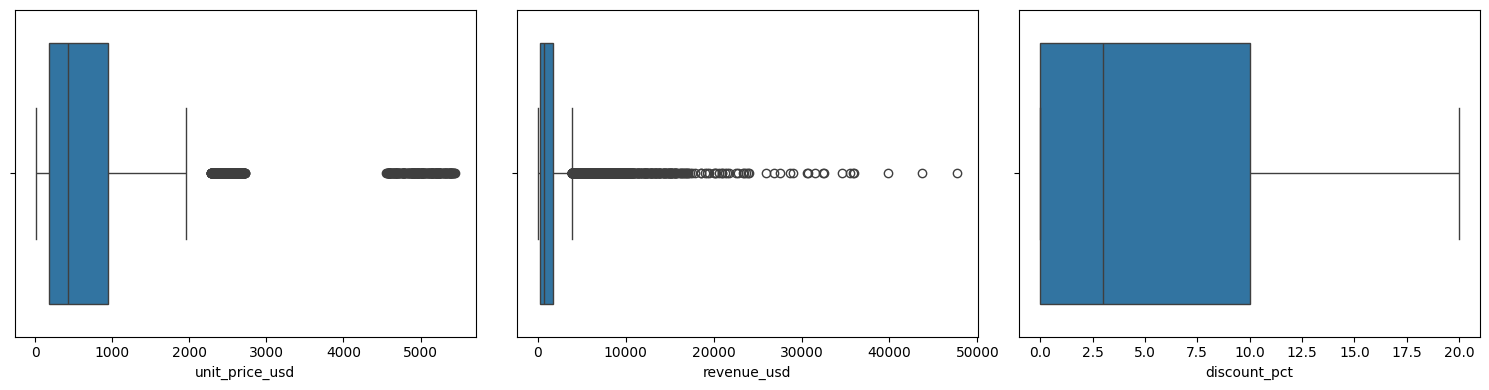

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='unit_price_usd', ax=axes[0])
sns.boxplot(data=df, x='revenue_usd', ax=axes[1])
sns.boxplot(data=df, x='discount_pct', ax=axes[2])
plt.tight_layout()
plt.show()

In [70]:
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['is_5g'] = df['is_5g'].map({'Yes': 1, 'No': 0})
df['return_status'] = df['return_status'].astype('category')
print(df.dtypes)

sale_id                           object
sale_date                 datetime64[ns]
year                               int64
quarter                           object
month                             object
country                           object
region                            object
city                              object
product_name                      object
category                          object
storage                           object
color                             object
is_5g                              int64
unit_price_usd                   float64
discount_pct                       int64
units_sold                         int64
discounted_price_usd             float64
revenue_usd                      float64
currency                          object
fx_rate_to_usd                   float64
revenue_local_currency           float64
sales_channel                     object
payment_method                    object
customer_segment                  object
customer_age_gro

In [71]:
df['discount_amount'] = df['unit_price_usd'] * df['discount_pct'] / 100
df['revenue_per_unit'] = df['revenue_usd'] / df['units_sold']
df['is_high_discount'] = (df['discount_pct'] > 10).astype(int)
df['month_num'] = df['sale_date'].dt.month
df[['discount_amount', 'revenue_per_unit', 'is_high_discount', 'month_num']].head()

,discount_amount,revenue_per_unit,is_high_discount,month_num
0,0.0000,1246.77,0,1
1,80.9840,728.86,0,3
2,49.2228,360.97,1,5
3,0.0000,242.69,0,7
4,0.0000,1562.98,0,9


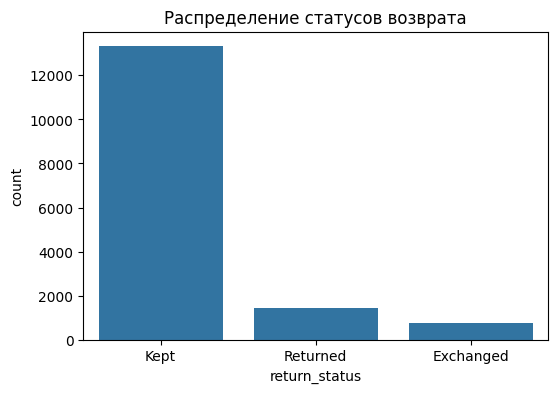

return_status
Kept         0.859032
Returned     0.092065
Exchanged    0.048903
Name: proportion, dtype: float64


In [72]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='return_status', order=df['return_status'].value_counts().index)
plt.title('Распределение статусов возврата')
plt.show()
print(df['return_status'].value_counts(normalize=True))

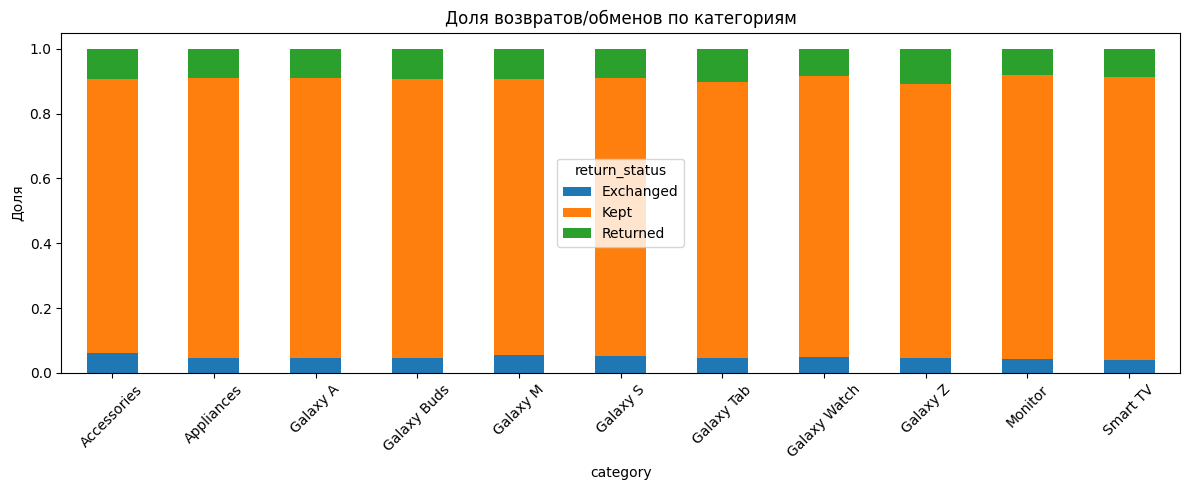

In [73]:
cross = pd.crosstab(df['category'], df['return_status'], normalize='index')
cross.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title('Доля возвратов/обменов по категориям')
plt.ylabel('Доля')
plt.xticks(rotation=45)
plt.legend(title='return_status')
plt.tight_layout()
plt.show()

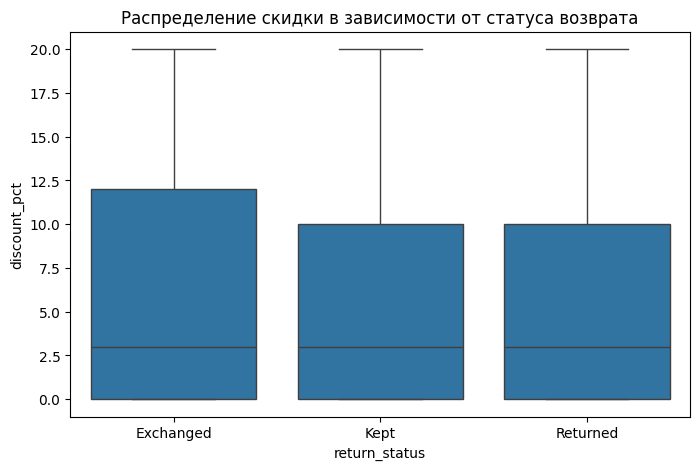

In [74]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='return_status', y='discount_pct')
plt.title('Распределение скидки в зависимости от статуса возврата')
plt.show()

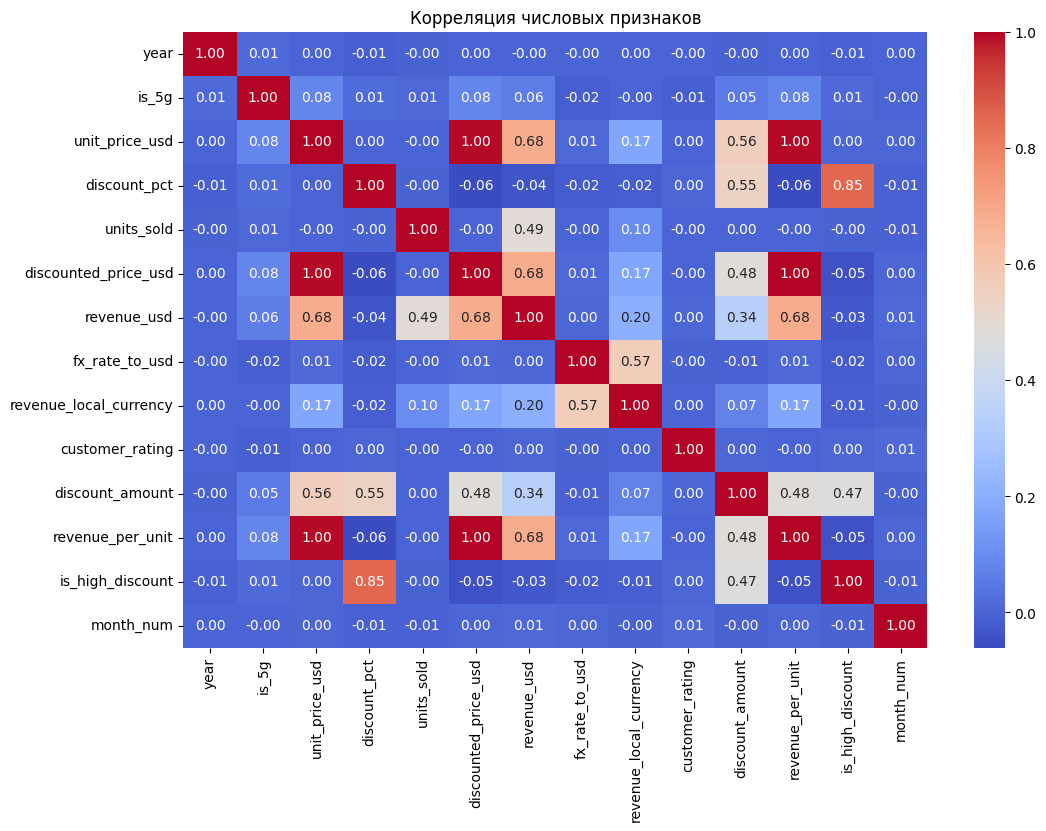

In [75]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

In [76]:
X = df.drop(columns=['return_status', 'sale_id', 'sale_date'])
y = df['return_status']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (12400, 29), Val: (1550, 29), Test: (1550, 29)


In [77]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_val_scaled = scaler.transform(X_val[numeric_features])

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

acc_lr = accuracy_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr, average='macro')
print(f"Logistic Regression: Accuracy={acc_lr:.4f}, F1-macro={f1_lr:.4f}")
print(classification_report(y_val, y_pred_lr))

Logistic Regression: Accuracy=0.8587, F1-macro=0.3080
              precision    recall  f1-score   support

   Exchanged       0.00      0.00      0.00        76
        Kept       0.86      1.00      0.92      1331
    Returned       0.00      0.00      0.00       143

    accuracy                           0.86      1550
   macro avg       0.29      0.33      0.31      1550
weighted avg       0.74      0.86      0.79      1550



C:\Users\я\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\я\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\я\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [78]:
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features_full = X_train.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features_full),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
print("Размерность после обработки:", X_train_processed.shape)

Размерность после обработки: (12400, 844)


In [79]:
print("Размерность X_train_processed:", X_train_processed.shape)
print("Размерность X_train числовые:", X_train[numeric_features].shape)

Размерность X_train_processed: (12400, 844)
Размерность X_train числовые: (12400, 14)


In [80]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [81]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_processed, y_train_enc)
y_pred_rf = rf.predict(X_val_processed)
acc_rf = accuracy_score(y_val_enc, y_pred_rf)
f1_rf = f1_score(y_val_enc, y_pred_rf, average='macro')
print(f"RandomForest: Accuracy={acc_rf:.4f}, F1-macro={f1_rf:.4f}")

RandomForest: Accuracy=0.8587, F1-macro=0.3080


In [82]:
classes = np.unique(y_train_enc)
weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[i] for i in y_train_enc])

In [83]:
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb.fit(X_train_processed, y_train_enc, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_val_processed)
acc_xgb = accuracy_score(y_val_enc, y_pred_xgb)
f1_xgb = f1_score(y_val_enc, y_pred_xgb, average='macro')
print(f"XGBoost: Accuracy={acc_xgb:.4f}, F1-macro={f1_xgb:.4f}")

XGBoost: Accuracy=0.5768, F1-macro=0.3092


In [84]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'RandomForest', 'XGBoost'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb],
    'F1-macro': [f1_lr, f1_rf, f1_xgb]
})
results

,Model,Accuracy,F1-macro
0,Logistic Regression,0.858710,0.307995
1,RandomForest,0.858710,0.307995
2,XGBoost,0.576774,0.309178
